# CNN and GRU for Time Series Forecasting

**Competition:** https://www.kaggle.com/competitions/ts-forecasting/overview

In this notebook we experiment with three architectures for univariate time series forecasting:
- **GRU** — recurrent model
- **CNN** — 1-D convolutional model
- **CNN-GRU** — hybrid model combining local pattern extraction with temporal modeling

# Metrics

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12.0, 4.0)

np.random.seed(1)
torch.manual_seed(1)


In [2]:
def _clip01(x):
    """
    Clip a value to the range [0, 1].

    Arguments:
    x -- float, value to clip

    Returns:
    clipped -- float, value clipped to [0, 1]
    """
    return float(np.minimum(np.maximum(x, 0.0), 1.0))


def weighted_rmse_score(y_target, y_pred, w):
    """
    Compute the weighted RMSE score used in the competition.

    Arguments:
    y_target -- numpy array of shape (m,), ground truth values
    y_pred   -- numpy array of shape (m,), predicted values
    w        -- numpy array of shape (m,), sample weights

    Returns:
    score -- float in [0, 1], higher is better
    """
    denom = np.sum(w * y_target ** 2)
    ratio = np.sum(w * (y_target - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))


# Data

In [3]:
train = pd.read_parquet('train.parquet')
train = train.tail(500_000).reset_index(drop=True)

print("train shape: " + str(train.shape))
train.head()


train shape: (500000, 94)


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,4KUR2ZOZ__TIB0QL9Q__DPPUO5X2__10__211,4KUR2ZOZ,TIB0QL9Q,DPPUO5X2,10,211,154,4.841981,3.944837,13.562372,...,-0.000303,-0.000517,-0.022924,-0.000744,0.114596,5.703215,0.057614,3,-0.120470,271.193305
1,4KUR2ZOZ__TIB0QL9Q__DPPUO5X2__25__211,4KUR2ZOZ,TIB0QL9Q,DPPUO5X2,25,211,139,7.384040,14.305558,12.455412,...,-0.000303,-0.000517,-0.022924,-0.000744,0.114596,5.703215,0.057614,3,-0.315813,172.842786
2,4KUR2ZOZ__TIB0QL9Q__DPPUO5X2__10__212,4KUR2ZOZ,TIB0QL9Q,DPPUO5X2,10,212,153,11.896580,7.098741,10.651581,...,-0.000307,-0.000519,-0.023267,NaN,0.084718,5.926226,0.060259,3,-0.349320,276.948415
3,4KUR2ZOZ__TIB0QL9Q__DPPUO5X2__3__212,4KUR2ZOZ,TIB0QL9Q,DPPUO5X2,3,212,160,5.126015,3.496434,8.209088,...,-0.000307,-0.000519,-0.023267,NaN,0.084718,5.926226,0.060259,3,-0.307838,294.263364
4,4KUR2ZOZ__TIB0QL9Q__DPPUO5X2__1__212,4KUR2ZOZ,TIB0QL9Q,DPPUO5X2,1,212,162,12.649625,6.773426,16.928146,...,-0.000307,-0.000519,-0.023267,NaN,0.084718,5.926226,0.060259,3,-0.143649,403.899454


In [4]:
test = pd.read_parquet('test.parquet')

print("test shape: " + str(test.shape))
test.head()


test shape: (1447107, 92)


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
0,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,3,3647,95,10.365266,3.209321,8.109339,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
1,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3647,88,2.571477,15.234848,16.505699,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
2,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,25,3647,71,5.524709,6.931663,8.939537,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
3,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647,W2MW3G2L,495MGHFJ,PZ9S1Z4V,1,3647,97,10.293758,14.893660,9.435544,...,-0.000832,-0.032241,-0.000830,-0.058961,-0.002774,-0.001480,-0.25646,1.665532,0.071324,2
4,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648,W2MW3G2L,495MGHFJ,PZ9S1Z4V,10,3648,87,14.776194,7.701180,6.228968,...,-0.000844,-0.032988,-0.000841,-0.059835,-0.002838,-0.001501,-0.24224,1.671890,0.071100,2


# Data Preprocessing

For the baseline experiments we extract the `y_target` column and treat all rows as a single
univariate time series. We normalize the values to `[-1, 1]`, then create fixed-length sliding
window sequences: each input `X` is a window of `sequence_length` past values and the
label `y` is the immediately following value.

> **Note:** This simplification ignores individual series identities (`id`, `ts_index`).
> It serves as a fast baseline for comparing architectural choices.

# Model Architectures

In [5]:
def normalize_series(data):
    """
    Fit a MinMaxScaler on data and return the scaled array and the fitted scaler.

    Arguments:
    data -- numpy array of shape (m, 1), raw time series values

    Returns:
    data_scaled -- numpy array of shape (m, 1), values normalized to [-1, 1]
    scaler      -- fitted MinMaxScaler instance
    """
    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_scaled = scaler.fit_transform(data)
    return data_scaled, scaler


def create_sequences(data, sequence_length):
    """
    Create sliding-window input/output pairs for next-step time series prediction.

    Arguments:
    data            -- numpy array of shape (m, 1), normalized time series
    sequence_length -- int, number of past steps used as input

    Returns:
    X -- numpy array of shape (m - sequence_length, sequence_length, 1), input sequences
    y -- numpy array of shape (m - sequence_length, 1), next-step targets
    """
    xs, ys = [], []
    for i in range(len(data) - sequence_length):
        xs.append(data[i : i + sequence_length])
        ys.append(data[i + sequence_length])
    return np.array(xs), np.array(ys)


In [6]:
sequence_length = 20
batch_size = 64

# Extract and normalize the target column
time_series = train['y_target'].values.astype(float).reshape(-1, 1)
time_series_scaled, scaler = normalize_series(time_series)

# Build sequences
X, y = create_sequences(time_series_scaled, sequence_length)

# Convert to PyTorch tensors
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

# DataLoader
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("X_tensor shape: " + str(tuple(X_tensor.shape)))
print("y_tensor shape: " + str(tuple(y_tensor.shape)))


X_tensor shape: (499980, 20, 1)
y_tensor shape: (499980, 1)


## GRU

In [7]:
class GRUModel(nn.Module):
    """
    Gated Recurrent Unit model for univariate time series prediction.

    Architecture:
    GRU (num_layers) --> Linear
    """

    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        """
        Arguments:
        input_size  -- int, number of input features per time step
        hidden_size -- int, number of GRU hidden units
        output_size -- int, number of output values
        num_layers  -- int, number of stacked GRU layers (default: 1)
        """
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Arguments:
        x -- tensor of shape (batch_size, sequence_length, input_size)

        Returns:
        out -- tensor of shape (batch_size, output_size)
        """
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out


## CNN

In [8]:
class CNNModel(nn.Module):
    """
    1-D Convolutional Neural Network model for time series prediction.

    Architecture:
    Conv1D --> ReLU --> MaxPool1D --> Flatten --> Linear
    """

    def __init__(self, input_channels, output_size, kernel_size=3, num_filters=64, seq_len=20):
        """
        Arguments:
        input_channels -- int, number of input channels (1 for univariate)
        output_size    -- int, number of output values
        kernel_size    -- int, convolution kernel size (default: 3)
        num_filters    -- int, number of convolution filters (default: 64)
        seq_len        -- int, input sequence length, used to compute FC input size (default: 20)
        """
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, num_filters, kernel_size, padding='same')
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        fc_input_size = num_filters * (seq_len // 2)
        self.fc = nn.Linear(fc_input_size, output_size)

    def forward(self, x):
        """
        Arguments:
        x -- tensor of shape (batch_size, sequence_length, input_channels)

        Returns:
        out -- tensor of shape (batch_size, output_size)
        """
        x = x.permute(0, 2, 1)        # (batch_size, input_channels, sequence_length)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.reshape(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x


## CNN-GRU Hybrid

In [9]:
class CNNGRUModel(nn.Module):
    """
    Hybrid CNN-GRU model: convolutional layers extract local patterns,
    then a GRU captures long-range temporal dependencies.

    Architecture:
    Conv1D --> ReLU --> MaxPool1D --> GRU (num_layers) --> Linear
    """

    def __init__(self, input_channels, hidden_size, output_size,
                 kernel_size=3, num_filters=32, num_layers=1):
        """
        Arguments:
        input_channels -- int, number of input channels (1 for univariate)
        hidden_size    -- int, number of GRU hidden units
        output_size    -- int, number of output values
        kernel_size    -- int, convolution kernel size (default: 3)
        num_filters    -- int, number of convolution filters (default: 32)
        num_layers     -- int, number of stacked GRU layers (default: 1)
        """
        super(CNNGRUModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.conv1 = nn.Conv1d(input_channels, num_filters, kernel_size, padding='same')
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.gru = nn.GRU(num_filters, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Arguments:
        x -- tensor of shape (batch_size, sequence_length, input_channels)

        Returns:
        out -- tensor of shape (batch_size, output_size)
        """
        x = x.permute(0, 2, 1)              # (batch_size, input_channels, sequence_length)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = x.permute(0, 2, 1)              # (batch_size, seq_len // 2, num_filters)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out


# Training

In [10]:
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, print_cost=True):
    """
    Train a PyTorch model and record the mean loss per epoch.

    Arguments:
    model       -- nn.Module, the model to train
    dataloader  -- DataLoader, yields (X_batch, y_batch) pairs
    criterion   -- loss function
    optimizer   -- torch.optim optimizer
    num_epochs  -- int, number of training epochs (default: 10)
    print_cost  -- bool, whether to print cost every 2 epochs (default: True)

    Returns:
    costs -- list of float, mean epoch loss recorded every 2 epochs
    """
    model.train()
    costs = []

    epoch_bar = tqdm(range(num_epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        epoch_loss = 0.0
        num_batches = 0

        batch_bar = tqdm(dataloader, desc="  Epoch {}/{}".format(epoch + 1, num_epochs),
                         leave=False, unit="batch")
        for X_batch, y_batch in batch_bar:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
            batch_bar.set_postfix(loss="{:.6f}".format(loss.item()))

        epoch_loss /= num_batches
        epoch_bar.set_postfix(avg_loss="{:.6f}".format(epoch_loss))

        if print_cost and (epoch + 1) % 2 == 0:
            print("Cost after epoch {}/{}: {:.6f}".format(epoch + 1, num_epochs, epoch_loss))
            costs.append(epoch_loss)

    return costs


def evaluate_model(model, X_tensor, y_tensor):
    """
    Evaluate a trained model on a dataset and return MSE loss.

    Arguments:
    model    -- nn.Module, trained model
    X_tensor -- tensor of shape (m, sequence_length, input_size)
    y_tensor -- tensor of shape (m, 1), ground truth values

    Returns:
    mse -- float, mean squared error on the provided dataset
    """
    model.eval()
    criterion = nn.MSELoss()
    with torch.no_grad():
        outputs = model(X_tensor)
        mse = criterion(outputs, y_tensor).item()
    model.train()
    return mse


# Experiments

We compare three architectures under identical training conditions (Adam, lr=0.001, 4 epochs):
- **GRU** — varying hidden size and number of layers
- **CNN** — varying number of filters and kernel size
- **CNN-GRU** — varying filter/hidden size combinations

## Experiment 1: GRU Architecture Variants

We vary the hidden size (32 vs 64) and the number of stacked layers (1 vs 2).

In [11]:
gru_configs = [
    {"hidden_size": 32, "num_layers": 1, "label": "GRU(H=32, L=1)"},
    {"hidden_size": 64, "num_layers": 1, "label": "GRU(H=64, L=1)"},
    {"hidden_size": 64, "num_layers": 2, "label": "GRU(H=64, L=2)"},
]

gru_results = {}

for cfg in gru_configs:
    print("\nTraining {}...".format(cfg["label"]))
    model = GRUModel(input_size=1, hidden_size=cfg["hidden_size"],
                     output_size=1, num_layers=cfg["num_layers"])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    costs = train_model(model, train_loader, criterion, optimizer, num_epochs=4, print_cost=True)
    mse = evaluate_model(model, X_tensor, y_tensor)
    gru_results[cfg["label"]] = {"costs": costs, "mse": mse, "model": model}
    print("Final MSE ({}): {:.6f}".format(cfg["label"], mse))



Training GRU(H=32, L=1)...
Cost after epoch 2/4: 0.001093
Cost after epoch 4/4: 0.001081
Final MSE (GRU(H=32, L=1)): 0.001140

Training GRU(H=64, L=1)...
Cost after epoch 2/4: 0.001094
Cost after epoch 4/4: 0.001080
Final MSE (GRU(H=64, L=1)): 0.001072

Training GRU(H=64, L=2)...
Cost after epoch 2/4: 0.001104
Cost after epoch 4/4: 0.001088
Final MSE (GRU(H=64, L=2)): 0.001117


## Experiment 2: CNN Architecture Variants

We vary the number of filters (32 vs 64) and the convolution kernel size (3 vs 5).

In [12]:
cnn_configs = [
    {"num_filters": 32, "kernel_size": 3, "label": "CNN(F=32, K=3)"},
    {"num_filters": 64, "kernel_size": 3, "label": "CNN(F=64, K=3)"},
    {"num_filters": 64, "kernel_size": 5, "label": "CNN(F=64, K=5)"},
]

cnn_results = {}

for cfg in cnn_configs:
    print("\nTraining {}...".format(cfg["label"]))
    model = CNNModel(input_channels=1, output_size=1,
                     kernel_size=cfg["kernel_size"],
                     num_filters=cfg["num_filters"],
                     seq_len=sequence_length)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    costs = train_model(model, train_loader, criterion, optimizer, num_epochs=4, print_cost=True)
    mse = evaluate_model(model, X_tensor, y_tensor)
    cnn_results[cfg["label"]] = {"costs": costs, "mse": mse, "model": model}
    print("Final MSE ({}): {:.6f}".format(cfg["label"], mse))



Training CNN(F=32, K=3)...
Cost after epoch 2/4: 0.001122
Cost after epoch 4/4: 0.001083
Final MSE (CNN(F=32, K=3)): 0.001066

Training CNN(F=64, K=3)...
Cost after epoch 2/4: 0.001123
Cost after epoch 4/4: 0.001081
Final MSE (CNN(F=64, K=3)): 0.001138

Training CNN(F=64, K=5)...
Cost after epoch 2/4: 0.001126
Cost after epoch 4/4: 0.001073
Final MSE (CNN(F=64, K=5)): 0.001037


## Experiment 3: CNN-GRU Hybrid Variants

The CNN extracts local temporal patterns; the GRU models long-range dependencies on top.
We vary the number of CNN filters and GRU hidden size.

In [13]:
hybrid_configs = [
    {"num_filters": 32, "hidden_size": 32, "num_layers": 1, "label": "CNN-GRU(F=32, H=32, L=1)"},
    {"num_filters": 32, "hidden_size": 64, "num_layers": 1, "label": "CNN-GRU(F=32, H=64, L=1)"},
    {"num_filters": 64, "hidden_size": 64, "num_layers": 2, "label": "CNN-GRU(F=64, H=64, L=2)"},
]

hybrid_results = {}

for cfg in hybrid_configs:
    print("\nTraining {}...".format(cfg["label"]))
    model = CNNGRUModel(input_channels=1,
                        hidden_size=cfg["hidden_size"],
                        output_size=1,
                        num_filters=cfg["num_filters"],
                        num_layers=cfg["num_layers"])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    costs = train_model(model, train_loader, criterion, optimizer, num_epochs=4, print_cost=True)
    mse = evaluate_model(model, X_tensor, y_tensor)
    hybrid_results[cfg["label"]] = {"costs": costs, "mse": mse, "model": model}
    print("Final MSE ({}): {:.6f}".format(cfg["label"], mse))



Training CNN-GRU(F=32, H=32, L=1)...
Cost after epoch 2/4: 0.001083
Cost after epoch 4/4: 0.001067
Final MSE (CNN-GRU(F=32, H=32, L=1)): 0.001115

Training CNN-GRU(F=32, H=64, L=1)...
Cost after epoch 2/4: 0.001089
Cost after epoch 4/4: 0.001066
Final MSE (CNN-GRU(F=32, H=64, L=1)): 0.001038

Training CNN-GRU(F=64, H=64, L=2)...
Cost after epoch 2/4: 0.001094
Cost after epoch 4/4: 0.001065
Final MSE (CNN-GRU(F=64, H=64, L=2)): 0.001056


# Results Comparison

Training curves (MSE per epoch) and final MSE bar chart across all configurations.

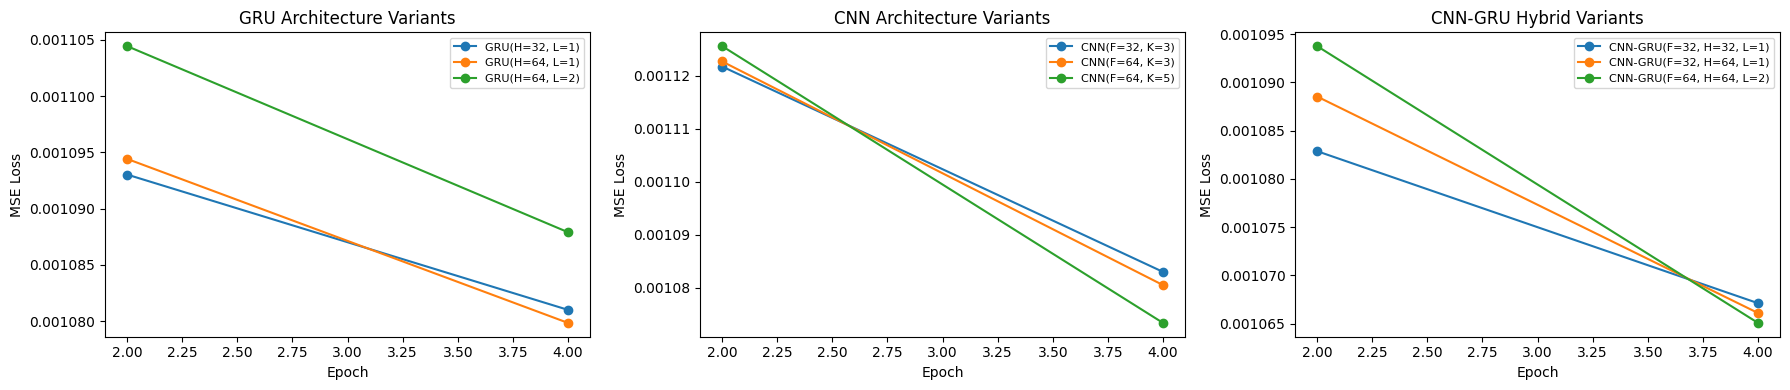

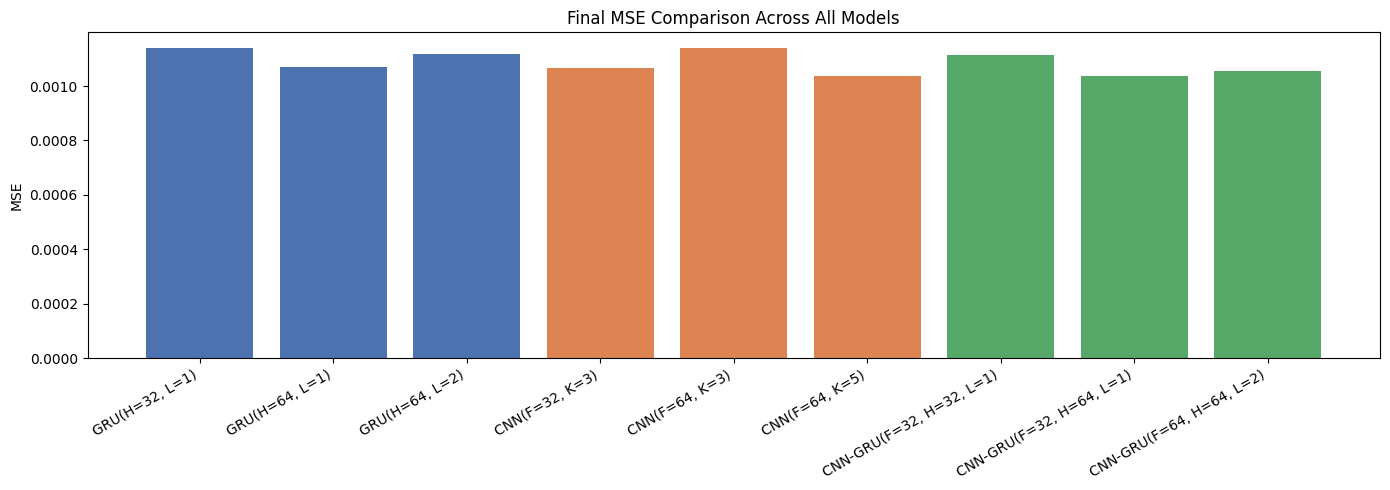


Ranking by MSE (lower is better):
                   Model      MSE
          CNN(F=64, K=5) 0.001037
CNN-GRU(F=32, H=64, L=1) 0.001038
CNN-GRU(F=64, H=64, L=2) 0.001056
          CNN(F=32, K=3) 0.001066
          GRU(H=64, L=1) 0.001072
CNN-GRU(F=32, H=32, L=1) 0.001115
          GRU(H=64, L=2) 0.001117
          CNN(F=64, K=3) 0.001138
          GRU(H=32, L=1) 0.001140


In [14]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (results, title) in zip(axes, [
    (gru_results,    "GRU Architecture Variants"),
    (cnn_results,    "CNN Architecture Variants"),
    (hybrid_results, "CNN-GRU Hybrid Variants"),
]):
    for label, info in results.items():
        epochs_recorded = range(2, 2 * len(info["costs"]) + 1, 2)
        ax.plot(epochs_recorded, info["costs"], marker='o', label=label)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()

# --- Final MSE bar chart ---
all_labels = (list(gru_results.keys()) +
              list(cnn_results.keys()) +
              list(hybrid_results.keys()))
all_mse = ([v["mse"] for v in gru_results.values()] +
           [v["mse"] for v in cnn_results.values()] +
           [v["mse"] for v in hybrid_results.values()])

colors = (["#4C72B0"] * len(gru_results) +
          ["#DD8452"] * len(cnn_results) +
          ["#55A868"] * len(hybrid_results))

plt.figure(figsize=(14, 5))
plt.bar(all_labels, all_mse, color=colors)
plt.xticks(rotation=30, ha="right")
plt.ylabel("MSE")
plt.title("Final MSE Comparison Across All Models")
plt.tight_layout()
plt.savefig("mse_comparison.png", dpi=100)
plt.show()

# --- Summary table ---
summary = pd.DataFrame({"Model": all_labels, "MSE": all_mse}).sort_values("MSE")
print("\nRanking by MSE (lower is better):")
print(summary.to_string(index=False))
